# Retail Data Quality and Cleaning Pipeline

---

## 1. Project Overview

Retail datasets often contain incomplete, inconsistent, or incorrectly encoded records that can compromise the reliability of downstream analysis.

This project assesses the quality of raw retail data from EverPeak and develops a reproducible data cleaning pipeline to transform the dataset into a reliable, analysis-ready source.

The analysis focuses on identifying data quality issues, defining appropriate cleaning strategies, standardizing the transformation process, and validating the resulting dataset before conducting exploratory retail analysis.

### 1.1 Analytical Questions

1. What data quality issues affect the reliability of the raw retail dataset?
2. Which issues can be corrected, imputed, or flagged without compromising data integrity?
3. How can the cleaning logic be standardized into a reproducible data cleaning pipeline?
4. How does the cleaning process improve the quality and analytical readiness of the dataset?
5. What retail patterns can be reliably explored after the data preparation process?

---

## 2. Data Loading and Initial Inspection

The raw retail dataset is loaded and inspected to understand its structure, available variables, and initial data types before performing any cleaning or transformation.


In [2]:
# Import libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Load dataset from GitHub

In [3]:
# Loading dataset

retail = pd.read_csv("everpeak_retail.csv")

In [4]:
# Inspect dataset structure

print(f"Dataset shape: {retail.shape}")
retail.head()

Dataset shape: (5008, 11)


,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
0,1,2024-02-02,2616,Sports,269,50,13385,credit_card,New York,NY,66.0
1,2,2024-10-10,1736,Grocery,66,0,660,debit_card,Los Angeles,CA,24.0
2,3,2024-08-27,2543,Sports,267,0,5073,credit_card,Chicago,IL,23.0
3,4,2024-06-09,2252,Toys,114,125,14290,credit_card,New York,NY,70.0
4,5,2024-06-07,1583,Fashion,729,16,11754,credit_card,Houston,TX,75.0


In [5]:
# Inspect data types and completeness

retail.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5008 entries, 0 to 5007
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   order_id          5008 non-null   int64  
 1   order_date        5000 non-null   object 
 2   customer_id       5008 non-null   int64  
 3   product_category  5008 non-null   object 
 4   price             5008 non-null   int64  
 5   quantity          5008 non-null   int64  
 6   order_value       5008 non-null   int64  
 7   payment_method    5008 non-null   object 
 8   city              4908 non-null   object 
 9   state             4908 non-null   object 
 10  customer_age      4858 non-null   float64
dtypes: float64(1), int64(5), object(5)
memory usage: 430.5+ KB


In [6]:
# Inspect numerical distributions

retail.describe()

,order_id,customer_id,price,quantity,order_value,customer_age
count,5008.000000,5008.000000,5008.000000,5008.000000,5008.000000,4858.000000
mean,2504.500000,1988.362420,756.187500,21.871406,10071.564696,43.728695
std,1445.829404,569.889309,1172.528065,63.303488,12398.053370,77.130195
min,1.000000,1000.000000,12.000000,0.000000,12.000000,-999.000000
25%,1252.750000,1495.000000,218.750000,0.000000,3096.250000,34.000000
50%,2504.500000,1988.000000,457.000000,0.000000,10339.500000,49.000000
75%,3756.250000,2475.000000,847.000000,22.000000,13159.250000,65.000000
max,5008.000000,2999.000000,36708.000000,1266.000000,303824.000000,80.000000


In [28]:
# Inspect categorical values

categorical_columns=["product_category", "payment_method", "city", "state"]

for column in categorical_columns:
    print(f"\n{column}:")
    print(retail[column].value_counts(dropna=False))


product_category:
Fashion        740
Electronics    736
Beauty         721
Toys           719
Sports         704
Grocery        684
Home           679
?               25
Name: product_category, dtype: int64

payment_method:
credit_card    2742
paypal         1175
debit_card      892
cash            199
Name: payment_method, dtype: int64

city:
Houston          514
Seattle          513
Los Angeles      511
New York         497
Miami            497
Phoenix          491
Chicago          482
Boston           474
San Francisco    468
Denver           461
NaN              100
Name: city, dtype: int64

state:
CA     979
TX     514
WA     513
FL     497
NY     497
AZ     491
IL     482
MA     474
CO     461
NaN    100
Name: state, dtype: int64


---

## 3. Data Quality Assessment

The raw dataset is systematically assessed to identify structural, semantic, and consistency issues that may affect analytical reliability. The assessment covers missing data, duplicate records, encoded sentinel values, invalid values, cross-variable inconsistencies, and suspicious distributions before any cleaning decisions are applied.

### 3.1 Missing Values

In [8]:
# Summarize missing values

missing_summary = pd.DataFrame({
    "missing_count": retail.isna().sum(),
    "missing_pct": retail.isna().mean() * 100
})

missing_summary =  missing_summary[missing_summary["missing_count"] > 0
                                  ].sort_values("missing_pct", ascending=False)

missing_summary

,missing_count,missing_pct
customer_age,150,2.995208
city,100,1.996805
state,100,1.996805
order_date,8,0.159744


In [9]:
# Check location missingness overlap

location_missing = pd.crosstab(
    retail["city"].isna(),
    retail["state"].isna()
)

location_missing

state,False,True
city,,
False,4908,0
True,0,100


In [10]:
# Assess invalid order dates

parsed_order_dates = pd.to_datetime(
    retail["order_date"],
    errors="coerce"
)

invalid_dates = (
    retail["order_date"].notna() &
    parsed_order_dates.isna()
).sum()

print("Missing dates:", retail["order_date"].isna().sum())
print("Invalid dates:", invalid_dates)

Missing dates: 8
Invalid dates: 0


In [114]:
# Inspect order date range

parsed_order_dates = pd.to_datetime(
    retail["order_date"],
    errors="coerce"
)

print("Minimum order date:", parsed_order_dates.min())
print("Maximum order date:", parsed_order_dates.max())

print("\nOrders by year:")
print(parsed_order_dates.dt.year.value_counts().sort_index())

Minimum order date: 2024-01-01 00:00:00
Maximum order date: 2026-12-30 00:00:00

Orders by year:
2024.0    4985
2026.0      15
Name: order_date, dtype: int64


In [115]:
# Inspect suspicious order dates

suspicious_dates = retail[
    parsed_order_dates.notna() &
    (parsed_order_dates.dt.year != 2024)
].copy()

suspicious_dates

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age
168,169,2026-05-12,1924,Grocery,55,196,10694,paypal,Chicago,IL,59.0
266,267,2026-11-02,2822,Fashion,425,0,5100,cash,Houston,TX,31.0
986,987,2026-05-26,2752,Home,943,12,11479,paypal,Boston,MA,74.0
1384,1385,2026-05-09,2347,Toys,1907,0,36233,credit_card,New York,NY,26.0
2482,2483,2026-03-01,1627,Sports,259,0,259,paypal,Denver,CO,45.0
2993,2994,2026-03-26,1175,Home,1069,0,12828,credit_card,Seattle,WA,48.0
3129,3130,2026-03-24,2078,Electronics,2561,0,17927,credit_card,Miami,FL,43.0
3294,3295,2026-07-25,2278,Grocery,458,0,5038,cash,Miami,FL,27.0
3407,3408,2026-04-26,2745,Fashion,327,44,14352,credit_card,New York,NY,74.0
3577,3578,2026-12-30,2040,Home,1353,0,18942,credit_card,Boston,MA,45.0


In [116]:
# Compare order activity by year and month

date_activity = retail.copy()

date_activity["parsed_order_date"] = pd.to_datetime(
    date_activity["order_date"],
    errors="coerce"
)

date_activity["order_year"] = (
    date_activity["parsed_order_date"].dt.year
)

date_activity["order_month"] = (
    date_activity["parsed_order_date"].dt.month
)

order_activity = (
    date_activity
    .dropna(subset=["parsed_order_date"])
    .groupby(["order_year", "order_month"])
    .size()
)

order_activity

order_year  order_month
2024.0      1.0            394
            2.0            441
            3.0            423
            4.0            415
            5.0            412
            6.0            426
            7.0            427
            8.0            391
            9.0            388
            10.0           427
            11.0           380
            12.0           461
2026.0      1.0              1
            2.0              1
            3.0              4
            4.0              1
            5.0              3
            7.0              2
            11.0             2
            12.0             1
dtype: int64

The dataset contains a dominant and continuous transaction period throughout 2024, with monthly order activity ranging from 380 to 461 records. In contrast, only 15 isolated records appear in 2026, with no observations in 2025.

Although these dates are syntactically valid, their temporal isolation indicates a potential consistency issue. The available data does not provide sufficient evidence to reconstruct the intended dates.

In [117]:
# Compare customer age missingness across categories

age_missing_comparison = (
    retail.assign(age_missing=retail["customer_age"].isna())
    .groupby("age_missing")[["product_category", "payment_method", "city"]]
    .nunique()
)

age_missing_comparison

,product_category,payment_method,city
age_missing,,,
False,8,4,10
True,7,4,10


In [12]:
# Identify categories without missing customer age

categories_with_missing_age = set(
    retail.loc[
        retail["customer_age"].isna(),
        "product_category"
    ]
)

categories_without_missing_age = (
    set(retail["product_category"].unique())
    - categories_with_missing_age
)

categories_without_missing_age

{'?'}

### 3.2 Duplicate Records

In [13]:
# Assess duplicate records

print("Duplicate rows:", retail.duplicated().sum())
print("Duplicate order IDs:", retail["order_id"].duplicated().sum())

Duplicate rows: 0
Duplicate order IDs: 0


### 3.3 Sentinel Values

In [14]:
# Assess known sentinel values

print(
    "Customer age sentinel (-999):",
    (retail["customer_age"] == -999).sum()
)

print(
    "Product category sentinel (?):",
    (retail["product_category"] == "?").sum()
)

Customer age sentinel (-999): 25
Product category sentinel (?): 25


In [15]:
# Check sentinel value overlap

sentinel_overlap = (
    (retail["customer_age"] == -999) &
    (retail["product_category"] == "?")
).sum()

print("Records with both sentinel values:", sentinel_overlap)

Records with both sentinel values: 0


### 3.4 Invalid and Impossible Values

In [16]:
# Assess invalid numerical values

print("Non-positive prices:", (retail["price"] <= 0).sum())

print("Negative quantities:", (retail["quantity"] < 0).sum())
print("Zero quantities:", (retail["quantity"] == 0).sum())

print("Non-positive order values:", (retail["order_value"] <= 0).sum())

print(
    "Invalid customer ages:",
    ((retail["customer_age"] < 0) | (retail["customer_age"] > 100)).sum()
)

Non-positive prices: 0
Negative quantities: 0
Zero quantities: 2971
Non-positive order values: 0
Invalid customer ages: 25


In [17]:
# Validate quantity reconstruction rule

valid_quantity = retail[retail["quantity"] > 0].copy()

calculated_quantity = (
    valid_quantity["order_value"] / valid_quantity["price"]
).round()

print(
    "Valid quantities matching calculated quantity:",
    (valid_quantity["quantity"] == calculated_quantity).sum()
)

print(
    "Valid quantities not matching calculated quantity:",
    (valid_quantity["quantity"] != calculated_quantity).sum()
)

Valid quantities matching calculated quantity: 1806
Valid quantities not matching calculated quantity: 231


In [18]:
# Assess quantity reconstruction differences

quantity_difference = (
    valid_quantity["quantity"] - calculated_quantity
).abs()

print(quantity_difference.value_counts().sort_index().head(10))
print("\nMaximum difference:", quantity_difference.max())

0.0     1806
1.0      156
2.0       28
3.0        5
4.0        3
5.0        5
6.0        5
7.0        1
8.0        2
11.0       1
dtype: int64

Maximum difference: 2081.0


In [19]:
# Inspect largest quantity reconstruction differences

quantity_comparison = valid_quantity[
    ["order_id", "price", "quantity", "order_value"]
].copy()

quantity_comparison["calculated_quantity"] = calculated_quantity
quantity_comparison["absolute_difference"] = quantity_difference

quantity_comparison.sort_values(
    "absolute_difference",
    ascending=False
).head(10)

,order_id,price,quantity,order_value,calculated_quantity,absolute_difference
4347,4348,22,2,45816,2083.0,2081.0
4641,4642,23,2,45695,1987.0,1985.0
1280,1281,25,2,45874,1835.0,1833.0
4047,4048,33,1,45783,1387.0,1386.0
155,156,36,1,45998,1278.0,1277.0
2417,2418,37,1,45723,1236.0,1235.0
796,797,45,1,45817,1018.0,1017.0
4947,4948,45,1,45697,1015.0,1014.0
2697,2698,54,1,45977,851.0,850.0
3838,3839,54,1,45977,851.0,850.0


In [20]:
# Compare order value across reconstruction results

quantity_comparison["reconstruction_match"] = (
    quantity_comparison["quantity"] ==
    quantity_comparison["calculated_quantity"]
)

quantity_comparison.groupby("reconstruction_match")["order_value"].describe()

,count,mean,std,min,25%,50%,75%,max
reconstruction_match,,,,,,,,
False,231.0,15653.978355,9657.849300,10037.0,11400.00,13015.0,14221.50,45998.0
True,1806.0,12469.115725,1706.186737,390.0,11243.75,12527.0,13837.25,15000.0


In [21]:
# Classify quantity reconstruction mismatches

reconstruction_errors = quantity_difference[quantity_difference > 0]

print(
    "Differences up to 2 units:",
    (reconstruction_errors <= 2).sum()
)

print(
    "Differences greater than 2 units:",
    (reconstruction_errors > 2).sum()
)

print(
    "Differences greater than 100 units:",
    (reconstruction_errors > 100).sum()
)

Differences up to 2 units: 184
Differences greater than 2 units: 47
Differences greater than 100 units: 21


In [22]:
# Assess city-state consistency

city_state_consistency = (retail.dropna(subset=["city", "state"])
    .groupby("city")["state"]
    .nunique()
)

print(
    "Cities linked to multiple states:",
    (city_state_consistency > 1).sum()
)

Cities linked to multiple states: 0


### 3.5 Suspicious Distributions and Potential Outliers

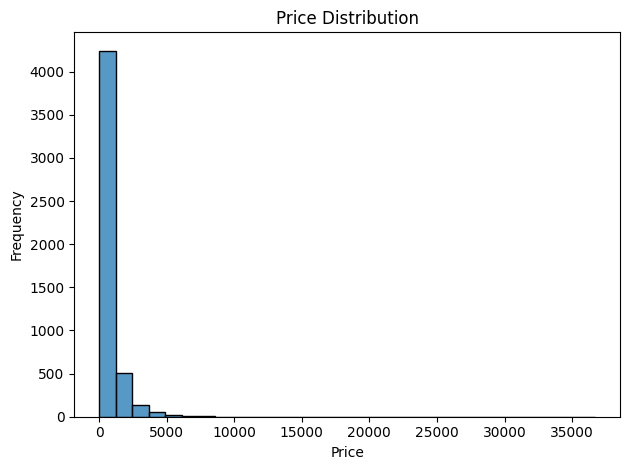

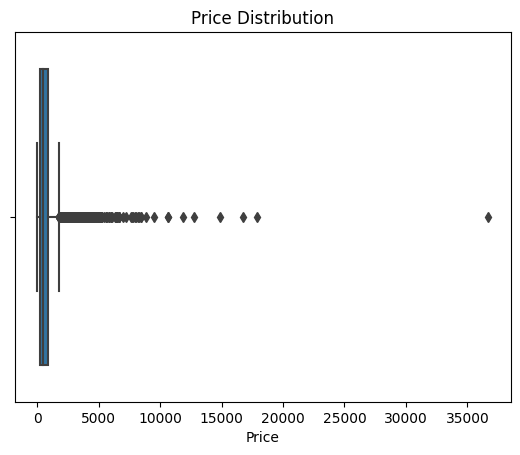

In [49]:
# Visualize price distribution

sns.histplot(data=retail, x="price", bins=30)
plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

sns.boxplot(x=retail["price"])
plt.title("Price Distribution")
plt.xlabel("Price")
plt.show()

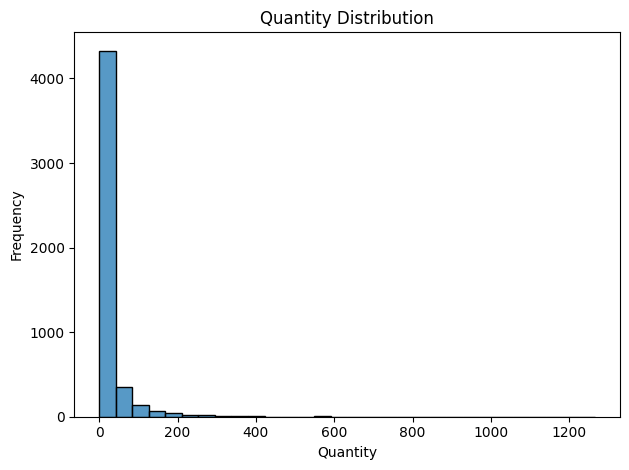

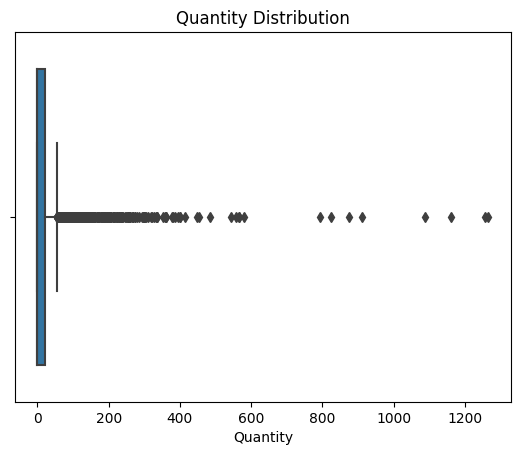

In [48]:
# Visualize quantity distribution

sns.histplot(data=retail, x="quantity", bins=30)
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

sns.boxplot(x=retail["quantity"])
plt.title("Quantity Distribution")
plt.xlabel("Quantity")
plt.show()

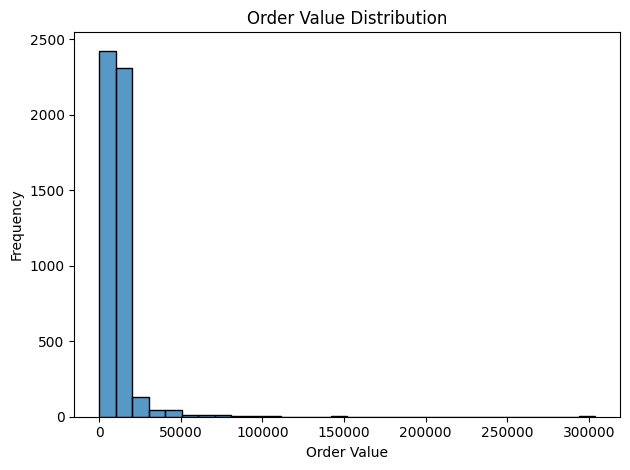

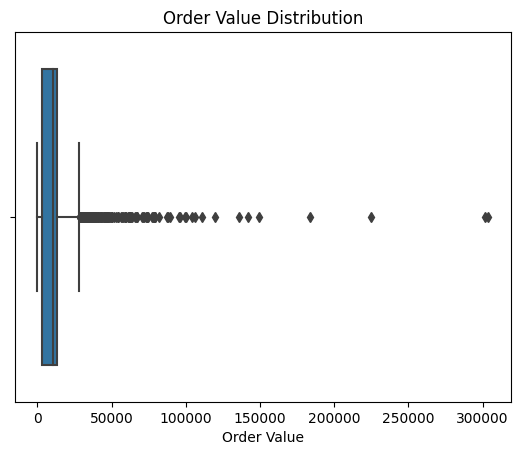

In [50]:
# Visualize order value distribution

sns.histplot(data=retail, x="order_value", bins=30)
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

sns.boxplot(x=retail["order_value"])
plt.title("Order Value Distribution")
plt.xlabel("Order Value")
plt.show()

In [34]:
# List of columns for outlier inspection

outlier_columns = ["price", "quantity", "order_value"]

In [35]:
# Quantify potential outliers

for column in outlier_columns:
    Q1 = retail[column].quantile(0.25)
    Q3 = retail[column].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = retail[
        (retail[column] < lower_bound) |
        (retail[column] > upper_bound)
    ]

    print(f"{column}: {len(outliers)} potential outliers")

price: 447 potential outliers
quantity: 527 potential outliers
order_value: 165 potential outliers


In [38]:
# Inspect extreme numerical values

for column in outlier_columns:
    print(f"\nTop 5 values for {column}:")
    print(retail[column].nlargest(5).to_list())


Top 5 values for price:
[36708, 17872, 16753, 14900, 12729]

Top 5 values for quantity:
[1266, 1258, 1161, 1088, 910]

Top 5 values for order_value:
[303824, 301554, 224884, 183540, 149000]


### 3.6 Key Findings

- Explicit missing values affect `customer_age`, location fields, and `order_date`. Missing `city` and `state` values occur in the same 100 records, indicating a shared missing-location pattern. In addition, 15 syntactically valid order dates appear as isolated temporal anomalies in 2026, outside the dominant and continuous 2024 transaction period.
- The dataset contains no duplicate rows or duplicated `order_id` values, and available city-state combinations are internally consistent.
- Encoded sentinel values affect 25 `customer_age` records (`-999`) and 25 `product_category` records (`?`). These issues affect separate records and are not detected by standard null checks.
- `quantity` presents the most significant structural issue: 2,971 records contain zero quantities despite positive order values. The `order_value / price` relationship reproduces 88.7% of observed positive quantities, but severe reconstruction errors in a small subset prevent treating it as an exact business rule.
- Numerical variables show right-skewed distributions and numerous IQR-based potential outliers. The observed `quantity` distribution is additionally distorted by the high frequency of zero values. A small number of isolated extreme observations are present, but statistical extremity alone is insufficient evidence for automatic removal.

---

## 4. Cleaning Strategy

Based on the data quality assessment, a cleaning strategy is defined before modifying the raw dataset. Each treatment is selected according to the type of issue, the available evidence, and the potential analytical impact of the transformation.

The objective is to preserve as much reliable information as possible while ensuring that cleaning decisions remain explicit, reproducible, and traceable.

### 4.1 Cleaning Decisions

| Data quality issue | Cleaning decision | Rationale |
|---|---|---|
| Missing `order_date` | Remove affected records | Orders without a valid date cannot support reliable temporal analysis. |
| Suspicious 2026 order dates | Preserve and flag as temporal anomalies | The dates are syntactically valid but isolated from the dominant 2024 transaction period. The available data does not support reliable date reconstruction. |
| Missing `city` and `state` | Preserve missing values | Location cannot be reliably inferred from the available variables. |
| Missing `customer_age` | Preserve as missing | Age should not be inferred without a defensible reconstruction rule. |
| `customer_age = -999` | Convert to missing | The value is an encoded sentinel and does not represent a valid age. |
| `product_category = ?` | Convert to missing | The value is an encoded sentinel and does not represent a valid product category. |
| `quantity = 0` | Reconstruct using `order_value / price` and flag reconstructed records | The relationship strongly reproduces observed positive quantities, but reconstructed values must remain distinguishable from recorded values. |
| Potential numerical outliers | Preserve values | Statistical extremity alone does not demonstrate data error. |

### 4.2 Cleaning Pipeline

The cleaning decisions are implemented on a copy of the raw dataset to preserve the original data and maintain a clear separation between source records and transformed data.

In [87]:
# Create working copy

retail_clean = retail.copy()

In [88]:
# Clean order dates

retail_clean["order_date"] = pd.to_datetime(
    retail_clean["order_date"],
    errors="coerce"
)

retail_clean = retail_clean.dropna(
    subset=["order_date"]
).reset_index(drop=True)

print("Remaining records:", len(retail_clean))

Remaining records: 5000


In [89]:
# Flag temporal anomalies

retail_clean["temporal_anomaly"] = (
    retail_clean["order_date"].dt.year != 2024
)

print(
    "Temporal anomalies:",
    retail_clean["temporal_anomaly"].sum()
)

Temporal anomalies: 15


In [90]:
# Replace customer age sentinel values

age_nulls_before = retail_clean["customer_age"].isna().sum()

retail_clean["customer_age"] = retail_clean["customer_age"].replace(-999, np.nan)

age_nulls_after = retail_clean["customer_age"].isna().sum()

print("Null values before:", age_nulls_before)
print("Null values after:", age_nulls_after)
print(
    "Remaining sentinel values:",
    (retail_clean["customer_age"] == -999).sum()
)

Null values before: 150
Null values after: 175
Remaining sentinel values: 0


In [91]:
# Replace product category sentinel values

category_nulls_before = retail_clean["product_category"].isna().sum()

retail_clean["product_category"] = retail_clean["product_category"].replace("?", np.nan)

category_nulls_after = retail_clean["product_category"].isna().sum()

print("Null values before:", category_nulls_before)
print("Null values after:", category_nulls_after)
print(
    "Remaining sentinel values:",
    (retail_clean["product_category"] == "?").sum()
)

Null values before: 0
Null values after: 25
Remaining sentinel values: 0


> **Decision Note — Quantity Reconstruction**
>
> Zero quantities are reconstructed because they conflict with positive `order_value` records and therefore represent a clear structural inconsistency. The reconstruction uses the rounded `order_value / price` relationship and preserves a `quantity_reconstructed` flag for traceability.
>
> Positive quantity mismatches are not automatically corrected. Although some records show severe cross-variable inconsistencies, the available data does not establish whether `quantity`, `price`, or `order_value` is incorrect. Replacing these values would require assuming that `quantity` is the corrupted variable without sufficient evidence.

In [92]:
# Flag reconstructed quantities for quantity = 0

retail_clean["quantity_reconstructed"] = (retail_clean["quantity"] == 0)

print(
    "Records flagged for quantity reconstruction:",
    retail_clean["quantity_reconstructed"].sum()
)

Records flagged for quantity reconstruction: 2966


In [93]:
# Reconstruct zero quantities

retail_clean.loc[
    retail_clean["quantity_reconstructed"],
    "quantity"
] = (
    retail_clean.loc[
        retail_clean["quantity_reconstructed"],
        "order_value"
    ]
    /
    retail_clean.loc[
        retail_clean["quantity_reconstructed"],
        "price"
    ]
).round()

print(
    "Zero quantities after reconstruction:",
    (retail_clean["quantity"] == 0).sum()
)

Zero quantities after reconstruction: 0


> **Decision Note — Cross-Variable Quantity Inconsistencies**
>
> Some records with positive quantities show severe differences between the recorded `quantity` and the value derived from `order_value / price`.
>
> These records are preserved rather than automatically corrected because the available data does not identify which variable (`quantity`, `price`, or `order_value`) is inaccurate. Records with an absolute reconstruction difference greater than 100 units are flagged as severe cross-variable inconsistencies for traceability.

In [97]:
# Flag severe quantity inconsistencies

calculated_quantity = (
    retail_clean["order_value"] /
    retail_clean["price"]
).round()

quantity_difference = (
    retail_clean["quantity"] - calculated_quantity
).abs()

retail_clean["quantity_inconsistency"] = (
    (~retail_clean["quantity_reconstructed"]) &
    (quantity_difference > 100)
)

print(
    "Severe quantity inconsistencies:",
    retail_clean["quantity_inconsistency"].sum()
)

Severe quantity inconsistencies: 21


> Smaller reconstruction differences are preserved without correction. Most mismatches differ by only one or two units, and the available data does not provide sufficient evidence to distinguish normal transactional variation from data error.

In [95]:
# Assess remaining missing values

missing_summary_clean = pd.DataFrame({
    "missing_count": retail_clean.isna().sum(),
    "missing_percentage": (retail_clean.isna().mean() * 100).round(2)
})

missing_summary_clean = (
    missing_summary_clean[missing_summary_clean["missing_count"] > 0]
    .sort_values("missing_percentage", ascending=False)
)

missing_summary_clean

,missing_count,missing_percentage
customer_age,175,3.5
city,100,2.0
state,100,2.0
product_category,25,0.5


**Missing Data Review**

The remaining missing values are intentionally preserved. No reliable reconstruction rule is available for `customer_age`, location fields, or `product_category`, and imputing these values would introduce unsupported assumptions into the cleaned dataset.

### 4.3 Pipeline Validation

The transformed dataset is validated against the expected outcomes of the cleaning strategy. These checks confirm that targeted quality issues were resolved while preserving intentionally missing or flagged records.

In [99]:
# Validate cleaned dataset

print("Dataset shape:", retail_clean.shape)
print("Order date type:", retail_clean["order_date"].dtype)
print("Missing order dates:", retail_clean["order_date"].isna().sum())

print(
    "Temporal anomalies:",
    retail_clean["temporal_anomaly"].sum()
)

print(
    "Customer age sentinel values:",
    (retail_clean["customer_age"] == -999).sum()
)

print(
    "Product category sentinel values:",
    (retail_clean["product_category"] == "?").sum()
)

print(
    "Zero quantities:",
    (retail_clean["quantity"] == 0).sum()
)

print(
    "Reconstructed quantities:",
    retail_clean["quantity_reconstructed"].sum()
)

print(
    "Severe quantity inconsistencies:",
    retail_clean["quantity_inconsistency"].sum()
)

Dataset shape: (5000, 14)
Order date type: datetime64[ns]
Missing order dates: 0
Temporal anomalies: 15
Customer age sentinel values: 0
Product category sentinel values: 0
Zero quantities: 0
Reconstructed quantities: 2966
Severe quantity inconsistencies: 21


### 4.4 Cleaning Impact Summary

The impact of the cleaning pipeline is summarized by comparing the original raw dataset with the validated cleaned dataset. This provides a concise record of the transformations applied and the unresolved quality issues preserved for traceability.

In [68]:
# Summarize cleaning impact

cleaning_impact = pd.DataFrame({
    "metric": [
        "Total records",
        "Missing order dates",
        "Customer age sentinel values",
        "Product category sentinel values",
        "Zero quantities"
    ],
    "raw_dataset": [
        len(retail),
        retail["order_date"].isna().sum(),
        (retail["customer_age"] == -999).sum(),
        (retail["product_category"] == "?").sum(),
        (retail["quantity"] == 0).sum()
    ],
    "clean_dataset": [
        len(retail_clean),
        retail_clean["order_date"].isna().sum(),
        (retail_clean["customer_age"] == -999).sum(),
        (retail_clean["product_category"] == "?").sum(),
        (retail_clean["quantity"] == 0).sum()
    ]
})

cleaning_impact

,metric,raw_dataset,clean_dataset
0,Total records,5008,5000
1,Missing order dates,8,0
2,Customer age sentinel values,25,0
3,Product category sentinel values,25,0
4,Zero quantities,2971,0


In [101]:
# Summarize pipeline traceability

print(
    "Temporal anomalies preserved:",
    retail_clean["temporal_anomaly"].sum()
)

print(
    "Reconstructed quantities:",
    retail_clean["quantity_reconstructed"].sum()
)

print(
    "Severe quantity inconsistencies preserved:",
    retail_clean["quantity_inconsistency"].sum()
)

Temporal anomalies preserved: 15
Reconstructed quantities: 2966
Severe quantity inconsistencies preserved: 21


The pipeline preserved 15 temporal anomalies through the `temporal_anomaly` flag and reconstructed 2,966 zero-quantity records while tracking them with `quantity_reconstructed`. An additional 21 records with severe quantity inconsistencies were retained and flagged rather than automatically corrected.

These flags preserve uncertain records while making their analytical limitations visible.

### 4.5 Reusable Cleaning Function

The validated cleaning logic is consolidated into a reusable function. The function applies the defined transformations to an independent copy of the input dataset and generates record-level flags to preserve the traceability of reconstructed and unresolved values.

In [118]:
# Define reusable cleaning function

def clean_retail_data(df):
    clean_df = df.copy()

    # Convert order dates
    clean_df["order_date"] = pd.to_datetime(clean_df["order_date"], errors="coerce")

    # Remove records with missing order dates
    clean_df = clean_df.dropna(subset=["order_date"]).reset_index(drop=True)
    
    # Flag temporal anomalies
    clean_df["temporal_anomaly"] = (clean_df["order_date"].dt.year != 2024)

    # Replace customer age sentinel values
    clean_df["customer_age"] = clean_df["customer_age"].replace(-999, np.nan)

    # Replace product category sentinel values
    clean_df["product_category"] = clean_df["product_category"].replace("?", np.nan)

    # Flag quantities requiring reconstruction
    clean_df["quantity_reconstructed"] = (clean_df["quantity"] == 0)

    # Reconstruct zero quantities
    clean_df.loc[
        clean_df["quantity_reconstructed"],
        "quantity"
    ] = (
        clean_df.loc[
            clean_df["quantity_reconstructed"],
            "order_value"
        ]
        /
        clean_df.loc[
            clean_df["quantity_reconstructed"],
            "price"
        ]
    ).round()
    
    # Calculate expected quantities
    calculated_quantity = (
        clean_df["order_value"] / clean_df["price"]
    ).round()

    # Calculate quantity reconstruction differences
    quantity_difference = (
        clean_df["quantity"] - calculated_quantity
    ).abs()

    # Flag severe quantity inconsistencies
    clean_df["quantity_inconsistency"] = (
        (~clean_df["quantity_reconstructed"]) & (quantity_difference > 100)
    )

    # Return cleaned dataset
    return clean_df

In [119]:
# Apply reusable cleaning function

retail_pipeline = clean_retail_data(retail)

retail_pipeline.head()

,order_id,order_date,customer_id,product_category,price,quantity,order_value,payment_method,city,state,customer_age,temporal_anomaly,quantity_reconstructed,quantity_inconsistency
0,1,2024-02-02,2616,Sports,269,50.0,13385,credit_card,New York,NY,66.0,False,False,False
1,2,2024-10-10,1736,Grocery,66,10.0,660,debit_card,Los Angeles,CA,24.0,False,True,False
2,3,2024-08-27,2543,Sports,267,19.0,5073,credit_card,Chicago,IL,23.0,False,True,False
3,4,2024-06-09,2252,Toys,114,125.0,14290,credit_card,New York,NY,70.0,False,False,False
4,5,2024-06-07,1583,Fashion,729,16.0,11754,credit_card,Houston,TX,75.0,False,False,False


In [120]:
# Compare cleaning pipeline results

print("Same shape:", retail_clean.shape == retail_pipeline.shape)

print("Same columns:", retail_clean.columns.equals(retail_pipeline.columns))

print("Same dataset:", retail_clean.equals(retail_pipeline))

Same shape: True
Same columns: True
Same dataset: True


The reusable cleaning function exactly reproduces the validated step-by-step cleaning process, confirming that the transformation logic can be consistently reapplied to the original dataset.

---


## 5. Exploratory Retail Analysis

After completing the data quality and cleaning pipeline, the prepared dataset can be used to explore selected retail patterns with greater analytical confidence.

This section focuses on a limited set of descriptive questions to demonstrate the analytical usability of the cleaned data rather than performing a comprehensive business performance analysis.

### 5.1 Order Activity Over Time

Monthly order activity is examined using the validated `order_date` field to identify broad temporal patterns in the prepared retail dataset.

In [121]:
# Filter temporally reliable records

temporal_orders = retail_pipeline[~retail_pipeline["temporal_anomaly"]].copy() # Temporal anomaly = False

In [137]:
# Aggregate monthly order activity

monthly_orders = (
    temporal_orders
    .groupby(temporal_orders["order_date"].dt.to_period("M"))["order_id"]
    .nunique()
    .reset_index(name="order_count")
)

monthly_orders["order_date"] = (monthly_orders["order_date"].dt.to_timestamp())

monthly_orders

,order_date,order_count
0,2024-01-01,394
1,2024-02-01,441
2,2024-03-01,423
3,2024-04-01,415
4,2024-05-01,412
5,2024-06-01,426
6,2024-07-01,427
7,2024-08-01,391
8,2024-09-01,388
9,2024-10-01,427


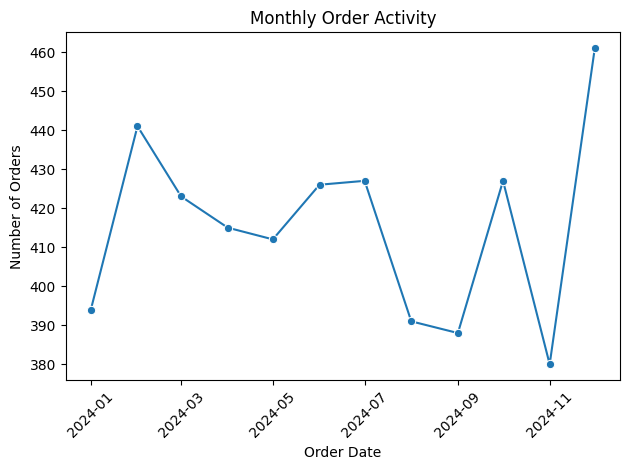

In [126]:
# Visualize monthly order activity

sns.lineplot(
    data=monthly_orders,
    x="order_date",
    y="order_count",
    marker="o"
)

plt.title("Monthly Order Activity")
plt.xlabel("Order Date")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Finding**

Monthly order activity remains relatively stable throughout 2024, ranging from 380 to 461 orders. December records the highest activity and November the lowest, but the single-year observation period does not provide sufficient evidence to identify recurring seasonal patterns.

### 5.2 Order Value Across Product Categories

Order value distributions are compared across product categories to identify differences in typical transaction values and the presence of extreme observations.

In [138]:
# Summarize order value by product category

category_order_value = (
    retail_pipeline
    .groupby("product_category")["order_value"]
    .agg(["count", "median", "mean", "max"])
    .round(2)
    .sort_values("median", ascending=False)
)

category_order_value

,count,median,mean,max
product_category,,,,
Electronics,735,12484.0,18260.60,303824
Home,679,10750.0,10214.10,100263
Sports,702,10569.5,10365.26,78964
Toys,715,8228.0,7903.38,36233
Fashion,739,8115.0,8745.14,224884
Beauty,721,7047.0,7889.29,45821
Grocery,684,4131.0,6943.14,45998


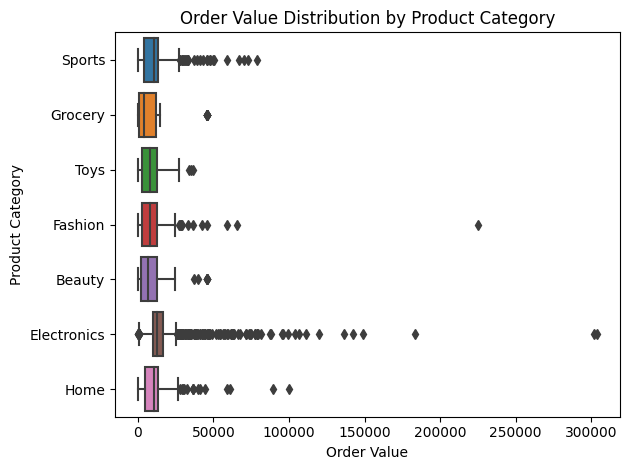

In [141]:
# Visualize order value by product category

sns.boxplot(
    data=retail_pipeline,
    x="order_value",
    y="product_category"
)

plt.title("Order Value Distribution by Product Category")
plt.xlabel("Order Value")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

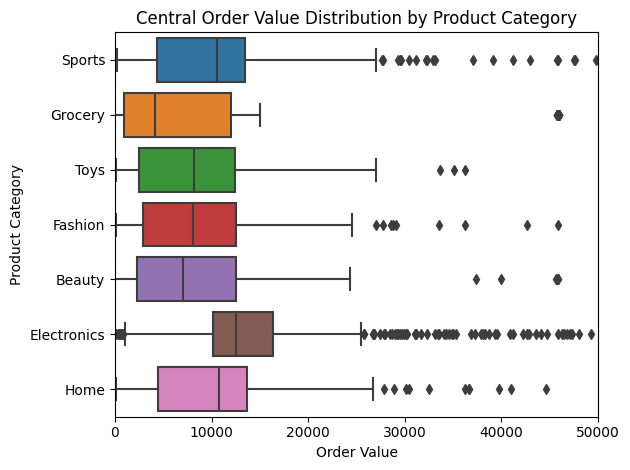

In [144]:
# Visualize central order value distributions

sns.boxplot(
    data=retail_pipeline,
    x="order_value",
    y="product_category"
)

plt.title("Central Order Value Distribution by Product Category")
plt.xlabel("Order Value")
plt.ylabel("Product Category")
plt.xlim(0, 50000)
plt.tight_layout()
plt.show()

**Finding**

Typical order values differ across product categories. `Electronics` records the highest median order value, while `Grocery` shows the lowest. The distributions remain right-skewed across categories, with particularly pronounced high-value observations in `Electronics`. Extreme individual orders substantially extend the overall scale but do not represent typical category-level transaction values.

### 5.3 Impact of Quantity Reconstruction

Recorded and reconstructed quantities are compared to assess how strongly quantity-based analysis depends on values generated by the cleaning pipeline.

The comparison focuses on the relative weight and distribution of both groups while recognizing that reconstructed quantities are derived from the `order_value / price` relationship and should not be interpreted as independently observed values.

In [145]:
# Compare reconstructed and recorded quantities

quantity_comparison = (
    retail_pipeline
    .groupby("quantity_reconstructed")["quantity"]
    .agg(["count", "median", "mean", "max"])
    .round(2)
)

quantity_comparison

,count,median,mean,max
quantity_reconstructed,,,,
False,2034,28.0,53.78,1266.0
True,2966,10.0,10.46,20.0


In [147]:
# Calculate quantity reconstruction rate

reconstruction_rate = (retail_pipeline["quantity_reconstructed"].mean() * 100)

print(f"Quantity reconstruction rate: {reconstruction_rate:.1f}%")

Quantity reconstruction rate: 59.3%


**Finding**

Reconstructed quantities represent 59.3% of the prepared dataset, meaning that quantity-based analysis depends predominantly on values derived by the cleaning pipeline rather than originally recorded observations.

Recorded and reconstructed quantities also show substantially different distributions. However, these differences should not be interpreted as independent retail patterns because reconstructed values are directly determined by the `order_value / price` rule. Quantity-based findings therefore require explicit consideration of reconstruction lineage.

### 5.4 Key Findings

- Monthly order activity remains broadly stable throughout the reliable 2024 observation period, with no sustained upward or downward trend and insufficient historical depth to establish recurring seasonality.
- Typical order values vary across product categories. `Electronics` shows the highest median order value, while `Grocery` records the lowest, and right-skewed distributions indicate that extreme transactions should not be treated as representative category behavior.
- Quantity-based analysis is highly dependent on the cleaning pipeline: 59.3% of quantity values were reconstructed rather than originally observed.
- The substantial distributional differences between recorded and reconstructed quantities cannot be interpreted as independent retail behavior because reconstructed values are directly derived from `order_value` and `price`.
- Record-level quality flags preserve uncertain observations while identifying when specific records may be unreliable for temporal or quantity-based analysis.

--- 

## 6. Conclusions

The data quality assessment identified several issues that could affect the reliability of the EverPeak retail dataset, including missing values, encoded sentinel values, zero quantities, isolated temporal anomalies, and cross-variable inconsistencies.

The cleaning pipeline standardized missing information, removed records without usable order dates, and reconstructed zero quantities using the available relationship between `order_value` and `price`. Because this reconstruction could not be treated as an exact business rule, reconstructed records were flagged to preserve their transformation history.

Records with suspicious 2026 dates and severe quantity inconsistencies were preserved rather than automatically corrected. The available data did not provide enough evidence to determine the correct replacement values. Quality flags were therefore used to identify when these records may be unreliable for temporal or quantity-based analysis.

After preparation, the dataset supports basic retail exploration. Monthly order activity remained relatively stable throughout 2024, and typical order values differed across product categories. However, 59.3% of quantity values were reconstructed, making quantity-based analysis highly dependent on the cleaning decisions applied in the pipeline.

Overall, the project shows that data cleaning is not limited to removing missing values or outliers. Reliable data preparation also requires identifying inconsistent records, testing possible reconstruction rules, documenting uncertain decisions, and preserving enough information to understand how the cleaned dataset was produced.

---

## 7. Data Export

The validated dataset is exported for reproducible use in future analysis. The processed file preserves the record-level quality flags created during the cleaning pipeline.

In [ ]:
# Export cleaned dataset

retail_pipeline.to_csv("../data/processed/retail_clean.csv", index=False)

print("Cleaned dataset exported successfully.")